In [1]:
import isofit
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.utils.apply_oe import apply_oe 

from collections import OrderedDict

import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt

# %matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [2]:
acorn = '/store/brodrick/col/acorn_atmospheric_correction_2019/acorn_mid_variable_vis/'
fp_mosaic = '/store/brodrick/col/mosaics/built_mosaic/min_phase_refl.hdr'

out_figs = '/store/carroll/col/figs/'

flights = ['NIS01_20180612_155442', 'NIS01_20180619_162542', 'NIS01_20180620_162340']

fp = glob(os.path.join(acorn, '*_refl_ciacorn.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.009361702..1.0].


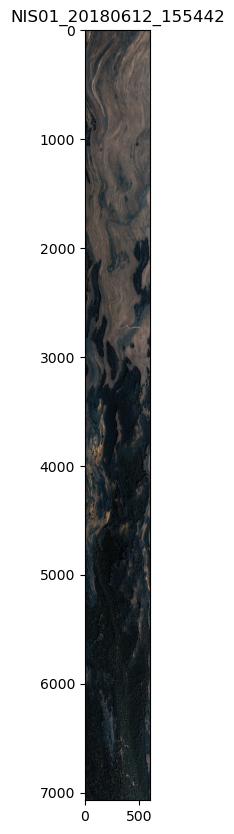

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07303482..1.0].


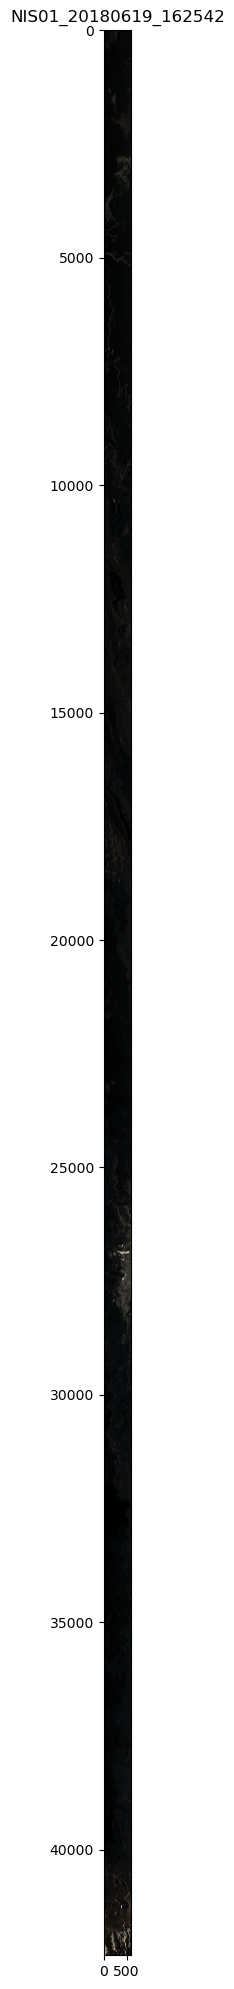

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003111327..1.0].


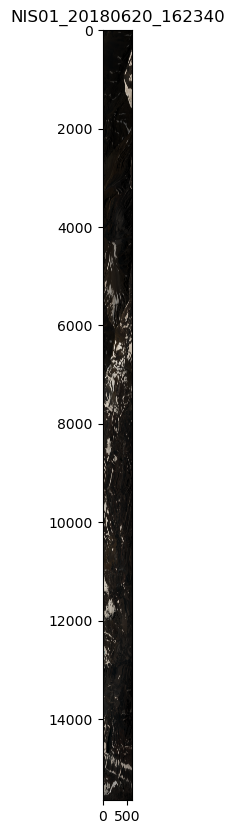

In [5]:
# just viz rfl rgb for flightlines

for i in range(len(flights)):
    flight = flights[i]
    fp = glob(os.path.join(acorn, f'{flight}*_refl_ciacorn.hdr'))[0]
    rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
    if i==1:
        fig = plt.figure(figsize=(5,25))
    else:
        fig = plt.figure(figsize=(5,10))
    plt.imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
    plt.title(flight)
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.009463722..1.0].


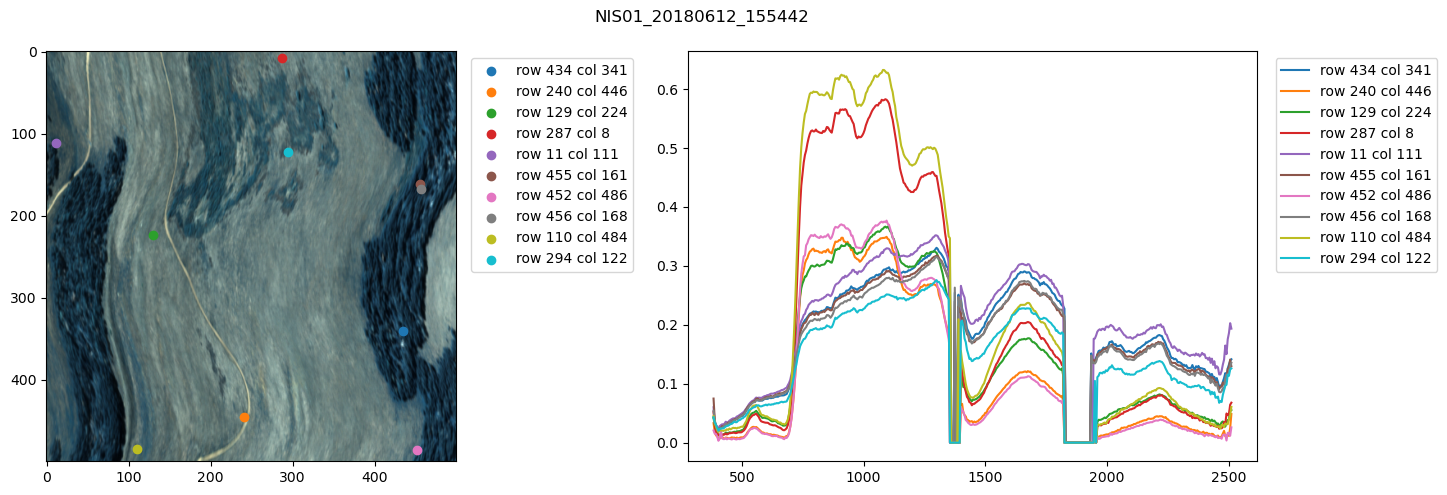

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0066691367..1.0].


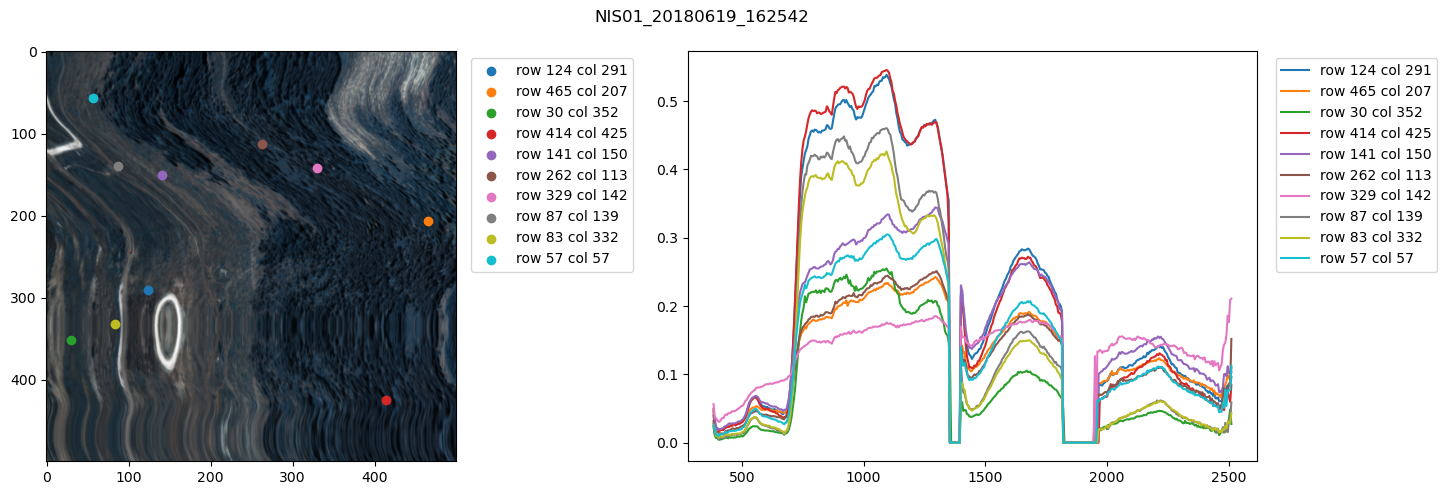

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0025544204..1.0].


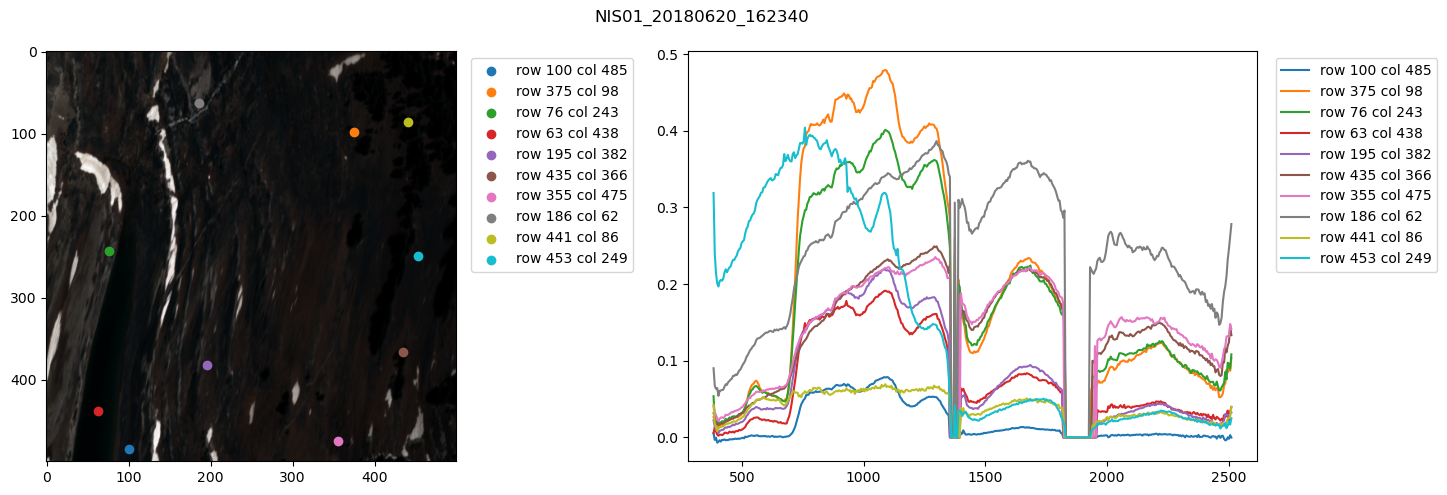

In [6]:
# plot some spectra from individual flightlines

size = 500
rowcol = [(2000, 50), (11000,50), (14000,50)]
n = 10 # n random points to plot

for i in range(len(flights)):
    flight = flights[i]
    row, col = rowcol[i]
    row2 = row+size; col2 = col+size
    fp = glob(os.path.join(acorn, f'{flight}*_refl_ciacorn.hdr'))[0]
    rfl = envi.open(fp).open_memmap()[row:row2,col:col2,:].copy()/10000
    rgb = rfl[...,(60,40,30)]

    rows = np.random.randint(0, rfl.shape[0], size=n)
    cols = np.random.randint(0, rfl.shape[1], size=n)
    
    fig, axs = plt.subplots(ncols=2, figsize=(15,5))
    axs[0].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
    for i in range(n):
        axs[1].plot(wl, rfl[rows[i], cols[i], :], label=f'row {rows[i]} col {cols[i]}')
        axs[0].scatter(rows[i], cols[i], label=f'row {rows[i]} col {cols[i]}')
    axs[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    axs[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    fig.suptitle(flight)
    plt.tight_layout()

    plt.savefig(os.path.join(out_figs, f'acorn_2018_{flight}.png'), dpi=300)
    
    plt.show()

/tmp/ipykernel_2263605/2714937837.py:17: RuntimeWarning: invalid value encountered in divide
  axs[0].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))


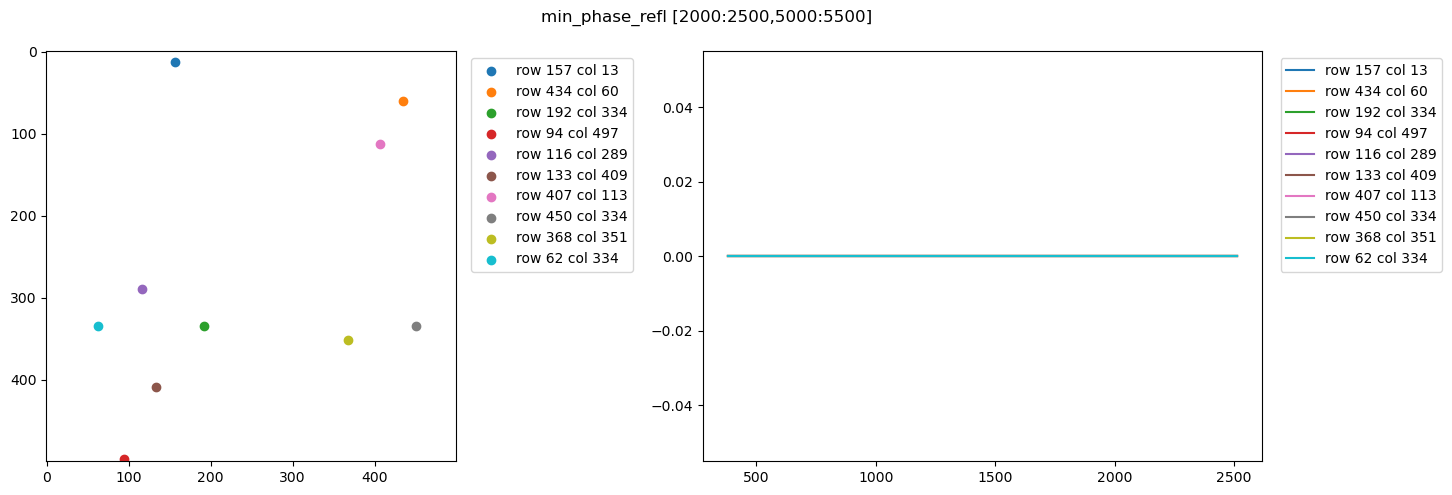

In [ ]:
# plot some spectra from the final mosaic
# jk the whole mosaic is zeros... ? Not worth downloading from ess-dive

size = 500
rowcol = [(2000, 5000), (11000,8000), (14000,10000)]
n = 10 # n random points to plot per subset area

for i in range(len(rowcol)):
    row, col = rowcol[i]
    row2 = row+size; col2 = col+size
    rfl = envi.open(fp_mosaic).open_memmap()[row:row2,col:col2,:].copy()/10000
    rgb = rfl[...,(60,40,30)]

    rows = np.random.randint(0, rfl.shape[0], size=n)
    cols = np.random.randint(0, rfl.shape[1], size=n)
    
    fig, axs = plt.subplots(ncols=2, figsize=(15,5))
    axs[0].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
    for i in range(n):
        axs[1].plot(wl, rfl[rows[i], cols[i], :], label=f'row {rows[i]} col {cols[i]}')
        axs[0].scatter(rows[i], cols[i], label=f'row {rows[i]} col {cols[i]}')
    axs[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    axs[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    fig.suptitle(f'min_phase_refl [{row}:{row2},{col}:{col2}]')
    plt.tight_layout()

    plt.savefig(os.path.join(out_figs, f'acorn_2018_mosaic_{i}.png'), dpi=300)
    
    plt.show()